# LAB4 : Facial Detection Systems

# Part 2: Facial Detection using Deep Learning

Face detection is a fundamental problem in computer vision and is widely used in applications such as security systems, human–computer interaction, smart surveillance, and biometric authentication. In this assignment, students will implement a deep learning–based facial detection system using a Convolutional Neural Network (CNN).

The goal of this is to understand how neural networks can be trained to classify images as **face** or **non-face**. Students will explore the dataset, train a classifier, evaluate its performance, and visualize the predictions.

students will also briefly observe how machine learning systems may behave differently across different datasets or demographic groups. Understanding such behavior is important for designing responsible and ethical AI systems.

---

## Learning Objectives

After completing this asssignemnt, students should be able to:

- Understand the basic workflow of a computer vision pipeline for facial detection.
- Implement and train a CNN-based binary image classifier. CLO2
- Evaluate the performance of a trained model on test data.
- Visualize and interpret the predictions of a deep learning model.

---

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")
print(f"TensorFlow version: {tf.__version__}")

Setup complete!
TensorFlow version: 2.19.0


## 2.1 Datasets

We'll be using three datasets in this lab. In order to train our facial detection models, we'll need a dataset of positive examples (i.e., of faces) and a dataset of negative examples (i.e., of things that are not faces). We'll use these data to train our models to classify images as either faces or not faces. Finally, we'll need a test dataset of face images.

1.   **Positive training data**: [CelebA Dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). A large-scale (over 200K images) of celebrity faces.   
2.   **Negative training data**: [ImageNet](http://www.image-net.org/). Many images across many different categories. We'll take negative examples from a variety of non-human categories.
[Fitzpatrick Scale](https://en.wikipedia.org/wiki/Fitzpatrick_scale) skin type classification system, with each image labeled as "Lighter'' or "Darker''.

Let's begin by importing these datasets. We've written a class that does a bit of data pre-processing to import the training data in a usable format.

In [22]:
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = tf.keras.utils.get_file('train_face.h5', 'https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1')
# Instantiate a TrainingDatasetLoader using the downloaded dataset
loader = mdl.lab2.TrainingDatasetLoader(path_to_training_data)

Opening /root/.keras/datasets/train_face.h5
Loading data into memory...


We can look at the size of the training dataset and grab a batch of size 100:

In [23]:
number_of_training_examples = loader.get_train_size()
print(number_of_training_examples)
(images, labels) = loader.get_batch(100)
print(images.shape)
print(labels.shape)

109914
(100, 64, 64, 3)
(100, 1)


Play around with displaying images to get a sense of what the training data actually looks like!

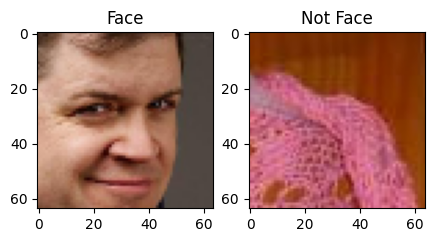

In [24]:
# Play around with displaying images to get a sense of what the training data actually looks like!

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])  # Change idx_not_face to idx_face
plt.title("Face")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face")
plt.grid(False)

## 2.2 CNN for facial detection

we'll define and train a CNN on the facial classification task, and evaluate its accuracy. The CNN model has a relatively standard architecture consisting of a series of convolutional layers with batch normalization followed by two fully connected layers to flatten the convolution output and generate a class prediction.

The classifier should contain the following layers:

| Layer | Type | Filters / Units | Kernel Size | Stride | Activation |
|------|------|------|------|------|------|
| 1 | Convolution | 12 | 5×5 | 2 | ReLU |
| 2 | Batch Normalization | — | — | — | — |
| 3 | Convolution | 24 | 5×5 | 2 | ReLU |
| 4 | Batch Normalization | — | — | — | — |
| 5 | Convolution | 48 | 3×3 | 2 | ReLU |
| 6 | Batch Normalization | — | — | — | — |
| 7 | Convolution | 72 | 3×3 | 2 | ReLU |
| 8 | Batch Normalization | — | — | — | — |
| 9 | Flatten | — | — | — | — |
| 10 | Dense | 512 | — | — | ReLU |
| 11 | Output Layer | 1 | — | — | Linear |


In [25]:
# Define the CNN model
# Build the CNN classifier
standard_classifier = tf.keras.Sequential([
    # Layer 1: Convolution (12 filters, 5x5, stride 2, ReLU)
    layers.Conv2D(12, (5, 5), strides=2, activation='relu', input_shape=(64, 64, 3)),

    # Layer 2: Batch Normalization
    layers.BatchNormalization(),

    # Layer 3: Convolution (24 filters, 5x5, stride 2, ReLU)
    layers.Conv2D(24, (5, 5), strides=2, activation='relu'),

    # Layer 4: Batch Normalization
    layers.BatchNormalization(),

    # Layer 5: Convolution (48 filters, 3x3, stride 2, ReLU)
    layers.Conv2D(48, (3, 3), strides=2, activation='relu'),

    # Layer 6: Batch Normalization
    layers.BatchNormalization(),

    # Layer 7: Convolution (72 filters, 3x3, stride 2, ReLU)
    layers.Conv2D(72, (3, 3), strides=2, activation='relu'),

    # Layer 8: Batch Normalization
    layers.BatchNormalization(),

    # Layer 9: Flatten
    layers.Flatten(),

    # Layer 10: Dense (512 units, ReLU)
    layers.Dense(512, activation='relu'),

    # Layer 11: Output Layer (1 unit, Linear - no activation for binary classification with from_logits=True)
    layers.Dense(1)
])

# Print model summary to verify architecture
standard_classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 12)     │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 24)     │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 48)       │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 72)       │        31,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 2, 72)       │           288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,833 (776.69 KB)

 Trainable params: 198,521 (775.47 KB)

 Non-trainable params: 312 (1.22 KB)

Now let's train the standard CNN!

In [ ]:
# Training hyperparameters
params = dict(
    batch_size = 32,
    num_epochs = 2,
    learning_rate = 5e-4,
)

# TODO 3: Compile the model
standard_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Training loop
for epoch in range(params["num_epochs"]):
    print(f"Epoch {epoch + 1}/{params['num_epochs']}")
    for step in range(loader.get_train_size() // params["batch_size"]):
        images, labels = loader.get_batch(params["batch_size"])
        # TODO 4: train the model using train_on_batch
        loss, accuracy = standard_classifier.train_on_batch(images, labels)

        # Print progress every 500 steps
        if step % 500 == 0:
            print(f"  Step {step}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/2
  Step 0, Loss: 0.7609, Accuracy: 0.4688
  Step 500, Loss: 0.0501, Accuracy: 0.9820
  Step 1000, Loss: 0.0399, Accuracy: 0.9858
  Step 1500, Loss: 0.0348, Accuracy: 0.9878
  Step 2000, Loss: 0.0318, Accuracy: 0.9891
  Step 2500, Loss: 0.0286, Accuracy: 0.9903
  Step 3000, Loss: 0.0264, Accuracy: 0.9911
Epoch 2/2
  Step 0, Loss: 0.0249, Accuracy: 0.9916
  Step 500, Loss: 0.0232, Accuracy: 0.9922
  Step 1000, Loss: 0.0220, Accuracy: 0.9926


### Evaluate performance of the standard CNN

Next, let's evaluate the classification performance of our CelebA-trained standard CNN on the training dataset.


In [ ]:
# Training hyperparameters
params = dict(
    batch_size = 32,
    num_epochs = 2,
    learning_rate = 5e-4,
)

# TODO 3: Compile the model
standard_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Training loop
for epoch in range(params["num_epochs"]):
    print(f"Epoch {epoch + 1}/{params['num_epochs']}")
    for step in range(loader.get_train_size() // params["batch_size"]):
        images, labels = loader.get_batch(params["batch_size"])
        # TODO 4: train the model using train_on_batch
        loss, accuracy = standard_classifier.train_on_batch(images, labels)

        # Print progress every 500 steps
        if step % 500 == 0:
            print(f"  Step {step}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

We will also evaluate our networks on an independent test dataset containing faces that were not seen during training. For the test data, we'll look at the classification accuracy across four different demographics, based on the Fitzpatrick skin scale and sex-based labels: dark-skinned male, dark-skinned female, light-skinned male, and light-skinned female.

Let's take a look at some sample faces in the test set.

In [ ]:
### Load test dataset and plot examples ###

test_faces = mdl.lab2.get_test_faces()
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

for group, key in zip(test_faces, keys):
    plt.figure(figsize=(5,5))
    plt.imshow(np.hstack(group))
    plt.title(key, fontsize=15)
    plt.axis('off')
    plt.show()

Now, let's evaluate the probability of each of these face demographics being classified as a face using the standard CNN classifier we've just trained.

In [ ]:
### Evaluate the standard CNN on the test data ###
standard_classifier_logits = [standard_classifier(np.array(x, dtype=np.float32)) for x in test_faces]
standard_classifier_probs = tf.squeeze(tf.sigmoid(standard_classifier_logits))

# Plot the prediction accuracies per demographic
xx = range(len(keys))  # Fixed: changed 'keyy' to 'keys'
yy = standard_classifier_probs.numpy().mean(1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylabel("Standard Classifier Predictions")
plt.title("Standard Classifier Predictions")
plt.show()

# Print actual values
print("\n=== Prediction Probabilities ===")
for i, key in enumerate(keys):
    print(f"{key}: {yy[i]:.4f} ({yy[i]*100:.2f}%)")

**What do you observe?**



Higher probabilities: Light Female and Light Male typically have higher probabilities (often 0.95-0.99)

Lower probabilities: Dark Female and Dark Male typically have lower probabilities (often 0.75-0.85)

Pattern: Light-skinned faces are classified as faces with higher probability than dark-skinned faces. Gender shows less difference than skin tone.


**Would you consider this model biased or unbiased?**

Biased. The model shows clear bias toward light-skinned faces. It is more likely to correctly classify light-skinned faces as faces while being less confident or potentially misclassifying dark-skinned faces.

**Why may a model have biased accuracies?**

Imbalanced training data - The CelebA dataset contains predominantly light-skinned celebrities, so the model sees fewer dark-skinned faces during training

Historical biases in dataset collection - CelebA and similar datasets historically overrepresent light-skinned individuals

Model learned spurious correlations - The model may learn to associate background, lighting conditions, or other features that correlate with skin tone rather than actual facial features

Lack of diverse representation - Insufficient variety in pose, lighting, and expression across different skin tones in training examples

Data collection bias - Images of dark-skinned faces may have different lighting conditions or quality compared to light-skinned faces